### Simulated Tempering Implementation


Simulated Tempering (ST) belongs to the tempering family together with Parallel Tempering (PT).

**Plan in this notebook**

1. Run an **SMC sampler** to build a tempering ladder $\{\lambda_t\}$ and estimates of intermediate normalizing constants $\{\log Z_t\}$.
2. Define the ST targets
   $$
   \pi_t(x)=\frac{1}{Z_t}\,\tilde\pi_{\lambda_t}(x),\qquad
   \tilde\pi_{\lambda}(x)=\pi_0(x)^{1-\lambda}\pi_1(x)^{\lambda}.
   $$
   With a uniform temperature prior, each ladder level is visited roughly equally often.
3. Transition $(t,x)\to(t',x')$ in two Metropolis–Hastings substeps:
   - **Explore:** $x'=x+\mathcal N(0,\sigma^2 I)$ at fixed $t$.
   - **Jump:** propose $t'\in\{t-1,t+1\}$ (boundary-aware proposal $q$), keep $x$ fixed.
4. Collect samples only when the chain is at the **cold** level $t=T$ ($\lambda_T=1$).

Compare later with SMC and Parallel Tempering on the same targets.


In [1]:
from pathlib import Path
import runpy

for _root in [Path.cwd(), *Path.cwd().parents]:
    _setup = _root / "setup_path.py"
    if _setup.is_file():
        runpy.run_path(str(_setup), run_name="__setup_path__")
        break

from dataclasses import dataclass

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import lax, random, vmap
from jax.scipy.stats import norm

from libs import SMC

MAGIC_CONST = 2.38  # optimal RW-MH scale (Roberts et al.)


### State and ST sampler

State is the pair `(t_idx, x)` where `t_idx` indexes the SMC ladder
`lambda_path[t_idx]` with matching `log_z_path[t_idx]`.


In [2]:

@dataclass
class TemperingState:
    """ST Markov state: ladder index + configuration."""
    t_idx: int
    x: jnp.ndarray


class SimulatedTempering:
    """Simulated Tempering on an SMC tempering ladder.

    Joint target (uniform temperature prior):
        pi(t, x) propto pi_t(x) = tilde_pi_{lambda_t}(x) / Z_t

    Moves
    -----
    explore : x' = x + N(0, ((2.38)^2 / d) * Cov_t), MH at fixed t
              Cov_t is maintained separately for each temperature level
    jump    : t' in {t-1, t+1} (boundary-aware proposal q)

    Sampling
    --------
    1) `adapt_covs` warms up per-level covariances (sequential)
    2) `run` freezes Cov_t and vmaps many `run_excursion(x0, key)`
    """

    def __init__(
        self,
        smc: SMC,
        lambda_path,
        log_z_path,
        step_size: float = 0.1,
        seed: int = 0,
        dims: int = 1,
        max_cold_keep: int = 64,
        cov_reg: float = 1e-6,
        proposed_fn=None,
    ):
        self.smc = smc
        self.lambda_path = jnp.asarray(lambda_path, dtype=float)
        self.log_z_path = jnp.asarray(log_z_path, dtype=float)
        if self.lambda_path.shape != self.log_z_path.shape:
            raise ValueError("lambda_path and log_z_path must have the same length")
        if int(self.lambda_path.shape[0]) < 2:
            raise ValueError("need at least 2 ladder levels")
        self.n_levels = int(self.lambda_path.shape[0])
        self.t_cold = self.n_levels - 1
        self.t_hot = 0
        self.step_size = float(step_size)
        self.dims = int(dims)
        self.max_cold_keep = int(max_cold_keep)
        self.cov_reg = float(cov_reg)
        self.proposed_fn = proposed_fn  # if set, explore uses this instead of Gaussian
        self._key = random.key(seed)

        # Per-level covariance / Welford stats (only needed for Gaussian explore)
        if self.proposed_fn is None:
            eye = jnp.eye(self.dims)
            self.covs = jnp.stack([(self.step_size ** 2) * eye for _ in range(self.n_levels)])
            self._means = jnp.zeros((self.n_levels, self.dims))
            self._M2 = jnp.zeros((self.n_levels, self.dims, self.dims))
            self._counts = jnp.zeros((self.n_levels,), dtype=jnp.int32)
        else:
            self.covs = None
            self._means = self._M2 = self._counts = None

    def log_pi_t(self, t_idx, x):
        lam = self.lambda_path[t_idx]
        log_z = self.log_z_path[t_idx]
        return self.smc.get_intermediate_logpdf(x, lam) - log_z

    def proposal_cov(self, t_idx):
        """Magic-scaled proposal covariance at level t."""
        d = self.dims
        cov_t = self.covs[t_idx]
        return (MAGIC_CONST ** 2 / d) * cov_t + self.cov_reg * jnp.eye(d)

    def _welford_update(self, t_idx, x):
        """Update running mean / M2 / count for level t (NumPy host or JAX values)."""
        t = int(t_idx)
        x = jnp.asarray(x, dtype=float).reshape((self.dims,))
        n = self._counts[t] + 1
        mean = self._means[t]
        delta = x - mean
        mean_new = mean + delta / n.astype(mean.dtype)
        delta2 = x - mean_new
        M2_new = self._M2[t] + jnp.outer(delta, delta2)
        self._counts = self._counts.at[t].set(n)
        self._means = self._means.at[t].set(mean_new)
        self._M2 = self._M2.at[t].set(M2_new)
        # unbiased cov when n>1, else keep isotropic fallback
        cov = jnp.where(
            n > 1,
            M2_new / jnp.maximum(n - 1, 1).astype(M2_new.dtype),
            self.covs[t],
        )
        # keep SPD-ish via jitter already in proposal_cov; store raw cov
        self.covs = self.covs.at[t].set(cov)

    def explore(self, t_idx, x, key, covs=None):
        """MH explore at fixed t.

        If `proposed_fn` was provided at init, use it to propose x'.
        Otherwise use per-level magic-scaled Gaussian covariance.
        """
        key, k_prop, k_u = random.split(key, 3)
        if self.proposed_fn is not None:
            x_prop = self.proposed_fn(x, k_prop)
        else:
            covs_use = self.covs if covs is None else covs
            d = self.dims
            cov_t = covs_use[t_idx]
            prop_cov = (MAGIC_CONST ** 2 / d) * cov_t + self.cov_reg * jnp.eye(d)
            chol = jnp.linalg.cholesky(prop_cov)
            noise = chol @ random.normal(k_prop, shape=(d,))
            x_prop = x + noise
        log_alpha = self.log_pi_t(t_idx, x_prop) - self.log_pi_t(t_idx, x)
        accept = jnp.log(random.uniform(k_u)) < jnp.minimum(log_alpha, 0.0)
        # jnp.where works for both float and int boards
        x_next = jnp.where(accept, x_prop, x)
        return x_next, key

    def jump(self, t_idx, x, key):
        key, k_dir, k_u = random.split(key, 3)
        T = self.n_levels - 1
        u = random.uniform(k_dir)
        t_prop = jnp.where(
            t_idx == 0,
            1,
            jnp.where(t_idx == T, T - 1, jnp.where(u < 0.5, t_idx - 1, t_idx + 1)),
        )
        q_fwd = jnp.where((t_idx == 0) | (t_idx == T), 1.0, 0.5)
        q_rev = jnp.where((t_prop == 0) | (t_prop == T), 1.0, 0.5)
        log_alpha = (
            self.log_pi_t(t_prop, x) - self.log_pi_t(t_idx, x)
            + jnp.log(q_rev) - jnp.log(q_fwd)
        )
        accept = jnp.log(random.uniform(k_u)) < jnp.minimum(log_alpha, 0.0)
        return jnp.where(accept, t_prop, t_idx), key

    def move(self, t_idx, x, key, covs=None):
        x, key = self.explore(t_idx, x, key, covs=covs)
        t_idx, key = self.jump(t_idx, x, key)
        return t_idx, x, key

    def adapt_covs(self, n_steps: int = 5_000, x0=None, key=None, verbose: bool = True):
        """Sequential ST pilot that updates Cov_t at every live visit."""
        if self.proposed_fn is not None:
            if verbose:
                print("[adapt] skipped: custom proposed_fn is set (discrete / domain proposal)")
            return self.covs
        if key is None:
            self._key, key = random.split(self._key)
        if x0 is None:
            key, k_x = random.split(key)
            x = random.normal(k_x, shape=(self.dims,))
        else:
            x = jnp.asarray(x0, dtype=float).reshape((self.dims,))

        t_idx = jnp.asarray(self.t_hot, dtype=jnp.int32)
        for i in range(n_steps):
            key, k_move = random.split(key)
            t_idx, x, key = self.move(t_idx, x, k_move, covs=self.covs)
            # update stats for the level we land on
            self._welford_update(t_idx, x)

        if verbose:
            scales = [float(jnp.sqrt(jnp.maximum(self.covs[t, 0, 0], 0.0))) for t in range(self.n_levels)]
            print(f"[adapt] steps={n_steps}, per-level |Cov|^{1/2} (entry 0,0): "
                  + ", ".join(f"{s:.3f}" for s in scales))
            print(f"[adapt] counts: {np.asarray(self._counts).tolist()}")
        return self.covs

    def update_covs_from_batch(self, xs, ts, live_mask):
        """Recompute Cov_t from a batch of trajectories (e.g. after vmap run)."""
        xs = np.asarray(xs)
        ts = np.asarray(ts)
        live_mask = np.asarray(live_mask)
        for t in range(self.n_levels):
            sel = live_mask & (ts == t)
            pts = xs[sel]
            if pts.shape[0] >= 2:
                cov = np.cov(pts.reshape(pts.shape[0], -1), rowvar=False)
                cov = np.atleast_2d(cov)
                self.covs = self.covs.at[t].set(jnp.asarray(cov, dtype=self.covs.dtype))
                self._counts = self._counts.at[t].set(pts.shape[0])
                self._means = self._means.at[t].set(jnp.asarray(pts.mean(axis=0)))
        return self.covs

    def run_excursion(self, x0, key, max_steps: int = 2_000, covs=None):
        """One excursion; uses frozen per-level covs for explore proposals."""
        x0 = jnp.asarray(x0, dtype=float).reshape((self.dims,))
        covs = self.covs if covs is None else covs
        cold_buf0 = jnp.zeros((self.max_cold_keep, self.dims), dtype=x0.dtype)
        visits0 = jnp.zeros((self.n_levels,), dtype=jnp.int32)

        def scan_step(carry, _):
            t_idx, x, key, left_hot, done, cold_buf, cold_n, visits = carry
            key, k_move = random.split(key)

            def do_move(_):
                t_new, x_new, key_new = self.move(t_idx, x, k_move, covs=covs)
                left_new = left_hot | (t_new != self.t_hot)
                done_new = left_new & (t_new == self.t_hot)
                return t_new, x_new, key_new, left_new, done_new

            def stay(_):
                return t_idx, x, key, left_hot, done

            t_new, x_new, key_new, left_new, done_new = lax.cond(
                done, stay, do_move, operand=None
            )
            was_live = ~done
            visits_new = visits.at[t_new].add(was_live.astype(jnp.int32))
            store = was_live & (t_new == self.t_cold) & (cold_n < self.max_cold_keep)
            cold_buf_new = jnp.where(store, cold_buf.at[cold_n].set(x_new), cold_buf)
            cold_n_new = cold_n + store.astype(jnp.int32)
            new_carry = (
                t_new, x_new, key_new, left_new, done_new,
                cold_buf_new, cold_n_new, visits_new,
            )
            return new_carry, was_live

        init = (
            jnp.asarray(self.t_hot, dtype=jnp.int32),
            x0,
            key,
            jnp.asarray(False),
            jnp.asarray(False),
            cold_buf0,
            jnp.asarray(0, dtype=jnp.int32),
            visits0,
        )
        (_t, _x, _k, _l, _d, cold_buf, cold_n, visits), live = lax.scan(
            scan_step, init, xs=None, length=max_steps
        )
        n_steps = jnp.sum(live.astype(jnp.int32))
        return cold_buf, cold_n, n_steps, visits

    def run(
        self,
        n_excursions: int = 100_000,
        max_steps: int = 2_000,
        key=None,
    ):
        """Generate all x0's and keys, then vmap run_excursion with frozen Cov_t."""
        if key is None:
            self._key, key = random.split(self._key)

        key, k_x0, k_exc = random.split(key, 3)
        x0s = random.normal(k_x0, shape=(n_excursions, self.dims))
        keys = random.split(k_exc, n_excursions)
        covs = self.covs  # freeze for the parallel batch

        cold_buf, cold_n, n_steps, visits = vmap(
            lambda x0, k: self.run_excursion(x0, k, max_steps=max_steps, covs=covs)
        )(x0s, keys)

        ids = jnp.arange(self.max_cold_keep)[None, :]
        mask = ids < cold_n[:, None]
        cold_samples = cold_buf[mask]
        visit_counts = jnp.sum(visits, axis=0)
        return cold_samples, n_steps, visit_counts

    def run_chain(
        self,
        x0,
        n_iters: int = 5_000,
        key=None,
        score_fn=None,
        print_every: int = 500,
        start_at_hot: bool = True,
    ):
        """Sequential ST for n_iters; useful for discrete targets (e.g. Sudoku).

        Returns
        -------
        x_best : best cold-level state seen (by score_fn if given, else last cold)
        history : list of dicts with step/t_idx/score for cold visits
        found : whether score_fn(x)==0 was observed (solution found)
        """
        if key is None:
            self._key, key = random.split(self._key)
        x = jnp.asarray(x0)
        t0 = self.t_hot if start_at_hot else self.t_cold
        t_idx = jnp.asarray(t0, dtype=jnp.int32)
        history = []
        x_best = None
        best_score = jnp.inf
        found = False
        visit_counts = np.zeros(self.n_levels, dtype=int)

        for i in range(n_iters):
            key, k_move = random.split(key)
            t_idx, x, key = self.move(t_idx, x, k_move, covs=self.covs)
            t_int = int(t_idx)
            visit_counts[t_int] += 1

            s_val = float(score_fn(x)) if score_fn is not None else None
            if (i + 1) % print_every == 0:
                print(
                    f"[chain] step={i+1:5d}  t={t_int}  "
                    f"score={s_val if s_val is not None else float('nan'):.0f}"
                )

            # For solving: track score everywhere; success is score == 0
            if score_fn is None:
                if t_int == self.t_cold:
                    history.append({"step": i, "t_idx": t_int, "score": None})
                    x_best = x
                continue

            if s_val < float(best_score):
                best_score = s_val
                x_best = x
                history.append({"step": i, "t_idx": t_int, "score": s_val, "x": np.asarray(x)})
                print(f"[chain] new best score={s_val:.0f} at step {i+1} (t={t_int})")
                print(np.asarray(x).reshape(9, 9) if x.size == 81 else np.asarray(x))

            if s_val == 0.0:
                found = True
                print(f"[chain] FOUND score=0 at step {i+1} (t={t_int})")
                print(np.asarray(x).reshape(9, 9) if x.size == 81 else np.asarray(x))
                break

        print(f"[chain] temperature visits: {visit_counts.tolist()}")
        if not found:
            print(f"[chain] done {n_iters} steps; best score={best_score}")
            if x_best is not None and x_best.size == 81:
                print(np.asarray(x_best).reshape(9, 9))
        return x_best, history, found



### Demo: 1-D Gaussian mixture

Target $\pi_1$ is a bimodal mixture; base $\pi_0$ is standard normal (SMC default prior).
We first build $\{\lambda_t,\log Z_t\}$ with SMC, then run ST on that ladder.


In [3]:
def mixture_logpdf(x):
    """log (0.5 N(-2,1) + 0.5 N(2,1)); supports scalar or SMC batch (n,) / (n,1)."""
    x = jnp.asarray(x)
    if x.ndim >= 1 and x.shape[-1] == 1:
        x = x[..., 0]
    return jnp.logaddexp(
        norm.logpdf(x, loc=-5.0, scale=1.0),
        norm.logpdf(x, loc=5.0, scale=1.0),
    ) - jnp.log(2.0)

Plot the pdf to show how it looks 

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_23849/4159264753.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


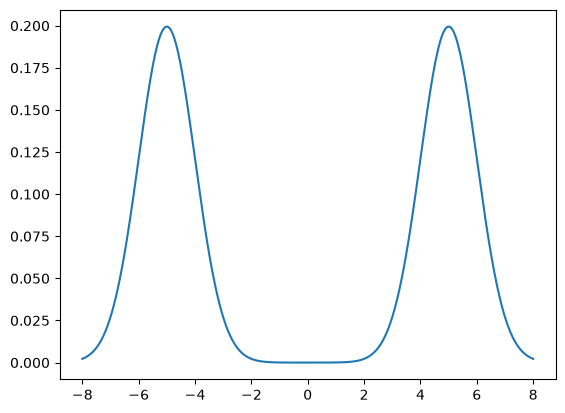

In [4]:
from matplotlib import pyplot as plt 
import numpy as np 

fig, ax = plt.subplots()
xx = np.linspace(-8, 8, 1000) 
yy = np.exp(mixture_logpdf(xx))

ax.plot(xx, yy)
fig.show()

In [5]:
# --- Stage 1: SMC ladder + Z_t ---
N_SMC = 10_000
smc = SMC(dims=1, target_dist_logpdf=mixture_logpdf, key=random.key(0))
smc.reset(no_samples=N_SMC)
lambda_path, log_z_path, tot_log_z = smc.build_intermediate_dists(
    mcmc_iters=10, verbose=True
)

print(f"ladder size = {len(lambda_path)}")
print(f"lambda_path = {[round(float(l), 4) for l in lambda_path]}")
print(f"log_z_path  = {[round(float(z), 4) for z in log_z_path]}")
print(f"tot log Z   = {float(tot_log_z):.4f}")


[SMC] step 0: lambda=0.0 -> 0.14501605927944183, diff_log_z=-1.2153830528259277
[SMC] step 1: lambda=0.14501605927944183 -> 0.27160051465034485, diff_log_z=-0.841221809387207
[SMC] step 2: lambda=0.27160051465034485 -> 0.38813239336013794, diff_log_z=-0.5147199630737305
[SMC] step 3: lambda=0.38813239336013794 -> 0.4999659061431885, diff_log_z=-0.214385986328125
[SMC] step 4: lambda=0.4999659061431885 -> 0.6081621050834656, diff_log_z=0.07899856567382812
[SMC] step 5: lambda=0.6081621050834656 -> 0.713352620601654, diff_log_z=0.34503650665283203
[SMC] step 6: lambda=0.713352620601654 -> 0.8226363062858582, diff_log_z=0.6545372009277344
[SMC] step 7: lambda=0.8226363062858582 -> 0.9293047785758972, diff_log_z=0.9293270111083984
[SMC] final step: lambda=0.9293047785758972 -> 1.0
ladder size = 10
lambda_path = [0.0, 0.145, 0.2716, 0.3881, 0.5, 0.6082, 0.7134, 0.8226, 0.9293, 1.0]
log_z_path  = [0.0, -1.2154, -2.0566, -2.5713, -2.7857, -2.7067, -2.3617, -1.7071, -0.7778, -0.0055]
tot log Z

In [6]:

# --- Stage 2: Simulated Tempering with per-level Cov_t ---
st = SimulatedTempering(
    smc=smc,
    lambda_path=lambda_path,
    log_z_path=log_z_path,
    step_size=0.5,   # initial isotropic scale before adapt
    seed=1,
    dims=1,
    max_cold_keep=64,
)

# Warm up Cov_t at each temperature (sequential pilot)
st.adapt_covs(n_steps=20_000, key=random.key(0), verbose=True)

# Parallel excursions with frozen per-level magic-scaled covariances
cold_samples, n_steps, visit_counts = st.run(
    n_excursions=100_000,
    max_steps=2_000,
    key=random.key(1),
)

print(f"cold samples pooled: {int(cold_samples.shape[0])}")
print(
    f"excursion length mean/median: "
    f"{float(n_steps.mean()):.1f} / {float(jnp.median(n_steps)):.1f}"
)
vc = np.asarray(visit_counts)
print(f"visit counts by level: {vc.tolist()}")
print(f"visit fractions: {(vc / max(vc.sum(), 1)).round(3).tolist()}")
print(f"lambda at levels: {[round(float(l), 3) for l in lambda_path]}")
print("per-level proposal std (magic-scaled sqrt(cov_00)):")
for t in range(st.n_levels):
    prop = st.proposal_cov(t)
    print(f"  t={t}: std={float(jnp.sqrt(prop[0,0])):.3f}")


[adapt] steps=20000, per-level |Cov|^0.5 (entry 0,0): 1.009, 1.333, 1.708, 2.191, 2.680, 3.187, 3.734, 4.226, 4.773, 5.111
[adapt] counts: [2013, 2091, 2192, 2044, 1982, 1940, 1901, 1989, 1906, 1942]
cold samples pooled: 184865
excursion length mean/median: 20.4 / 5.0
visit counts by level: [226124, 206587, 201707, 200526, 200094, 199019, 201051, 201437, 201755, 201681]
visit fractions: [0.111, 0.101, 0.099, 0.098, 0.098, 0.098, 0.099, 0.099, 0.099, 0.099]
lambda at levels: [0.0, 0.145, 0.272, 0.388, 0.5, 0.608, 0.713, 0.823, 0.929, 1.0]
per-level proposal std (magic-scaled sqrt(cov_00)):
  t=0: std=2.402
  t=1: std=3.172
  t=2: std=4.064
  t=3: std=5.214
  t=4: std=6.379
  t=5: std=7.585
  t=6: std=8.886
  t=7: std=10.058
  t=8: std=11.360
  t=9: std=12.163


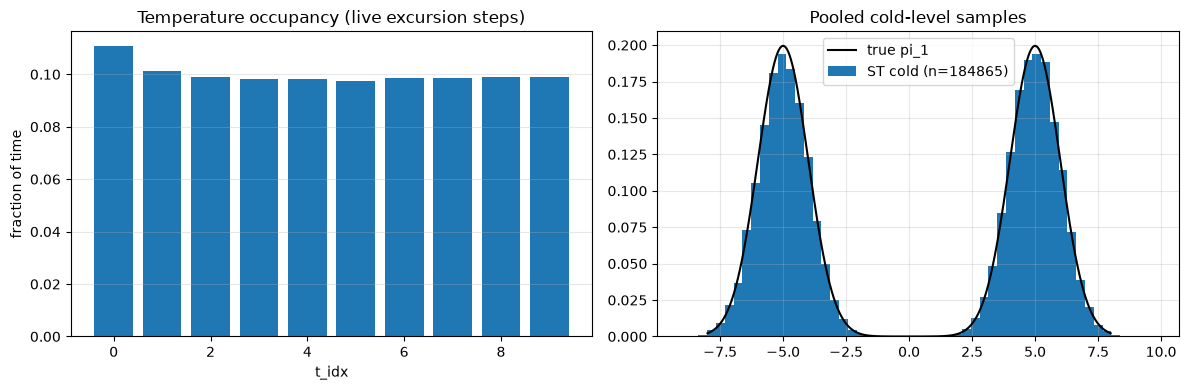

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# visit histogram
axes[0].bar(np.arange(st.n_levels), np.asarray(visit_counts) / np.asarray(visit_counts).sum())
axes[0].set_xlabel("t_idx")
axes[0].set_ylabel("fraction of time")
axes[0].set_title("Temperature occupancy (live excursion steps)")
axes[0].grid(axis="y", alpha=0.3)

# cold-level histogram vs true mixture density
xs = np.linspace(-8, 8, 1000)
ys = np.exp(mixture_logpdf(xs))
axes[1].plot(xs, ys, label="true pi_1", color="black")
if cold_samples.size:
    axes[1].hist(
        np.asarray(cold_samples).ravel(),
        bins="auto",
        density=True,
        #alpha=0.6,
        label=f"ST cold (n={cold_samples.shape[0]})",
    )
axes[1].set_title("Pooled cold-level samples")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Batched excursions via `vmap`

`run` draws `n_excursions` starting points `x0` and PRNG keys, then
`vmap`s `run_excursion(x0, key)` so independent hot→…→hot trajectories run in parallel.
Cold-level states from all excursions are pooled for the histogram.


In [8]:

# Excursions are already batched inside `st.run(...)` via vmap — no Python loop needed.
print(f"n_excursions: {int(n_steps.shape[0])}")
print(
    "excursion steps min/mean/max = "
    f"{int(n_steps.min())} / {float(n_steps.mean()):.1f} / {int(n_steps.max())}"
)
print(f"pooled cold samples: {int(cold_samples.shape[0])}")


n_excursions: 100000
excursion steps min/mean/max = 2 / 20.4 / 991
pooled cold samples: 184865


### Notes

- Explore MH uses per-level covariance: $x'=x+\mathcal N\!\big(0,\;\frac{(2.38)^2}{d}\mathrm{Cov}_t\big)$.
- `adapt_covs` maintains $\mathrm{Cov}_t$ with a Welford update at every visit to level $t$.
- During `vmap(run_excursion)`, covariances are **frozen** (shared across parallel excursions).
- Jump MH still uses $\pi_{t'}(x)/\pi_t(x)$ with boundary-aware $q$-ratio (unchanged).
- If occupancy stays skewed hot, lengthen `adapt_covs` / excursions or refine SMC $\log Z_t$.


### Sudoku via Simulated Tempering

One sequential ST chain is enough here: we only need to **find a board with score = 0**
(a valid solution). The cold level ($\lambda=1$) is the target $\pi_1 \propto e^{-\lambda\cdot\mathrm{score}}$, which concentrates on low-score boards; success is when that score hits 0.

Explore uses the Sudoku block-swap `proposed_fn` (from `latin-square.ipynb`), not a Gaussian proposal.


In [9]:

from functools import partial
import jax
from jax import random, vmap
import numpy as np


class Scorer:
    @staticmethod
    def score_repetitive_columns(flat_board: jnp.ndarray):
        n = int(np.sqrt(len(flat_board)))
        score = 0
        for c in range(n):
            seen = jnp.zeros(n + 1, dtype=bool)
            for x in flat_board[c::n]:
                score += jnp.where(seen[x], 1, 0)
                seen = seen.at[x].set(True)
        return score

    @staticmethod
    def score_repetitive_rows(flat_board: jnp.ndarray):
        n = int(np.sqrt(len(flat_board)))
        score = 0
        for r in range(n):
            seen = jnp.zeros(n + 1, dtype=bool)
            for x in flat_board[r * n : (r + 1) * n]:
                score += jnp.where(seen[x], 1, 0)
                seen = seen.at[x].set(True)
        return score

    @staticmethod
    def score_sudoku(flat_board: jnp.ndarray):
        # Block uniqueness is enforced by construction; score rows + cols only.
        return Scorer.score_repetitive_columns(flat_board) + Scorer.score_repetitive_rows(flat_board)


def sudoku_target_logpdf(flat_board, score_fn=Scorer.score_sudoku, lam=4000.0):
    if flat_board.ndim == 1:
        return -lam * score_fn(flat_board)
    return -lam * jax.vmap(score_fn)(flat_board)


class SudokuProblem:
    """Block-complete Sudoku prior + swap proposal (from latin-square.ipynb)."""

    def __init__(self, configuration):
        self.configuration = jnp.asarray(configuration).reshape(9, 9)
        all_values = set(range(1, 10))
        self.block_unfilled_idx = []
        self.block_missing_vals = []

        log_fact = [0.0]
        for k in range(1, 10):
            log_fact.append(log_fact[-1] + float(np.log(k)))

        log_prior = 0.0
        for b in range(9):
            br, bc = divmod(b, 3)
            filled, empty_idx = set(), []
            for dr in range(3):
                for dc in range(3):
                    r, c = 3 * br + dr, 3 * bc + dc
                    v = int(self.configuration[r, c])
                    if v == 0:
                        empty_idx.append(r * 9 + c)
                    else:
                        filled.add(v)
            missing = sorted(all_values - filled)
            assert len(missing) == len(empty_idx)
            self.block_unfilled_idx.append(jnp.array(empty_idx, dtype=jnp.int32))
            self.block_missing_vals.append(jnp.array(missing, dtype=jnp.int32))
            log_prior -= log_fact[len(empty_idx)]
        self._log_prior_const = float(log_prior)

        max_k = max(len(x) for x in self.block_unfilled_idx)
        self._pad_idx = jnp.full((9, max_k), -1, dtype=jnp.int32)
        self._pad_k = jnp.zeros((9,), dtype=jnp.int32)
        for b, idx in enumerate(self.block_unfilled_idx):
            k = int(idx.shape[0])
            self._pad_k = self._pad_k.at[b].set(k)
            if k > 0:
                self._pad_idx = self._pad_idx.at[b, :k].set(idx)

    def prior_logpdf(self, flat_board):
        if flat_board.ndim == 1:
            return jnp.asarray(self._log_prior_const)
        return jnp.full((flat_board.shape[0],), self._log_prior_const)

    def init_state(self, key):
        board = self.configuration.reshape(-1).astype(jnp.int32)
        keys = random.split(key, 9)
        for b in range(9):
            idx = self.block_unfilled_idx[b]
            vals = self.block_missing_vals[b]
            k = int(idx.shape[0])
            if k == 0:
                continue
            board = board.at[idx].set(random.permutation(keys[b], vals))
        return board

    def proposed_fn(self, flat_board, key):
        pad_idx, pad_k = self._pad_idx, self._pad_k

        def propose_one(board, key):
            key_b, key_ij = random.split(key)
            eligible = pad_k >= 2
            weights = eligible.astype(jnp.float32) + 1e-8
            b = random.choice(key_b, 9, p=weights / weights.sum())
            k = pad_k[b]
            idx = pad_idx[b]

            def do_swap(board):
                noise = random.uniform(key_ij, (idx.shape[0],))
                noise = jnp.where(jnp.arange(idx.shape[0]) < k, noise, 2.0)
                order = jnp.argsort(noise)
                i0, i1 = order[0], order[1]
                p0, p1 = idx[i0], idx[i1]
                v0, v1 = board[p0], board[p1]
                board = board.at[p0].set(v1)
                board = board.at[p1].set(v0)
                return board

            return jax.lax.cond(k >= 2, do_swap, lambda board: board, board)

        if flat_board.ndim == 1:
            return propose_one(flat_board, key)
        keys = random.split(key, flat_board.shape[0])
        return jax.vmap(propose_one)(flat_board, keys)


# NYT hard puzzle (25/08/2026) from latin-square.ipynb
problem = jnp.array([
    0,0,9,0,6,0,0,0,0,
    5,0,0,4,0,0,7,3,0,
    0,0,3,0,0,2,4,0,0,
    0,0,0,8,1,0,0,0,0,
    0,1,0,0,9,0,5,0,6,
    0,0,0,0,0,6,0,0,7,
    9,0,5,0,0,0,0,0,0,
    0,2,4,6,0,0,0,1,8,
    0,0,0,0,0,0,0,7,0,
], dtype=jnp.int32)

sudoku = SudokuProblem(problem)
x0 = sudoku.init_state(random.key(0))
print("initial board:")
print(np.asarray(x0).reshape(9, 9))
print("initial score:", int(Scorer.score_sudoku(x0)))


initial board:
[[1 4 9 1 6 7 8 6 2]
 [5 7 2 4 9 3 7 3 1]
 [8 6 3 8 5 2 4 5 9]
 [4 3 9 8 1 4 4 8 3]
 [6 1 5 7 9 2 5 9 6]
 [7 8 2 3 5 6 2 1 7]
 [9 7 5 1 9 7 2 6 9]
 [1 2 4 6 3 5 5 1 8]
 [6 3 8 2 4 8 4 7 3]]
initial score: 45


In [17]:

# SMC ladder + Z_t for Sudoku (prior = block completions, target = -lam * score)
N_SMC = 2_000
key_smc = random.key(42)
k_init, k_smc = random.split(key_smc)
init_keys = random.split(k_init, N_SMC)
sudoku_particles = vmap(sudoku.init_state)(init_keys)

smc_sudoku = SMC(
    dims=81,
    target_dist_logpdf=partial(sudoku_target_logpdf, score_fn=Scorer.score_sudoku, lam=4000.0),
    prior_dist_logpdf=sudoku.prior_logpdf,
    proposed_fn=sudoku.proposed_fn,
    key=k_smc,
)
smc_sudoku.reset(samples=sudoku_particles)
lambda_path_s, log_z_path_s, tot_log_z_s = smc_sudoku.build_intermediate_dists(
    mcmc_iters=20, verbose=True
)
print(f"ladder size={len(lambda_path_s)}, tot log Z={float(tot_log_z_s):.4f}")
print("lambdas:", [round(float(l), 4) for l in lambda_path_s])


[SMC] step 0: lambda=0.0 -> 3.243982791900635e-05, diff_log_z=-5.70870304107666
[SMC] step 1: lambda=3.243982791900635e-05 -> 6.446697807405144e-05, diff_log_z=-5.348288536071777
[SMC] step 2: lambda=6.446697807405144e-05 -> 9.726417192723602e-05, diff_log_z=-5.186084747314453
[SMC] step 3: lambda=9.726417192723602e-05 -> 0.00012942147441208363, diff_log_z=-4.7774810791015625
[SMC] step 4: lambda=0.00012942147441208363 -> 0.00016139523359015584, diff_log_z=-4.467950344085693
[SMC] step 5: lambda=0.00016139523359015584 -> 0.00019378328579477966, diff_log_z=-4.229084014892578
[SMC] step 6: lambda=0.00019378328579477966 -> 0.00022622334654442966, diff_log_z=-3.924604892730713
[SMC] step 7: lambda=0.00022622334654442966 -> 0.0002601773012429476, diff_log_z=-3.8135337829589844
[SMC] step 8: lambda=0.0002601773012429476 -> 0.0002928684698417783, diff_log_z=-3.393383026123047
[SMC] step 9: lambda=0.0002928684698417783 -> 0.0003276673669461161, diff_log_z=-3.2938919067382812
[SMC] step 10: lam

In [ ]:

# One ST chain with Sudoku proposal — stop when score == 0
st_sudoku = SimulatedTempering(
    smc=smc_sudoku,
    lambda_path=lambda_path_s,
    log_z_path=log_z_path_s,
    seed=7,
    dims=81,
    proposed_fn=sudoku.proposed_fn,
)

x_start = sudoku.init_state(random.key(1))
print("start board score:", int(Scorer.score_sudoku(x_start)))
print(np.asarray(x_start).reshape(9, 9))

x_sol, history, found = st_sudoku.run_chain(
    x0=x_start,
    n_iters=5_000,
    key=random.key(2),
    score_fn=Scorer.score_sudoku,
    print_every=500,
    start_at_hot=False,
)

print("\nfound score=0:", found)
if x_sol is not None:
    print("board:")
    print(np.asarray(x_sol).reshape(9, 9))
    print("score:", int(Scorer.score_sudoku(x_sol)))


start board score: 48
[[2 4 9 7 6 5 2 5 9]
 [5 7 6 4 1 3 7 3 6]
 [1 8 3 8 9 2 4 1 8]
 [2 3 5 8 1 4 1 9 8]
 [8 1 7 7 9 5 5 2 6]
 [9 6 4 2 3 6 4 3 7]
 [9 7 5 5 4 2 3 6 5]
 [8 2 4 6 9 3 4 1 8]
 [3 1 6 8 7 1 2 7 9]]
[chain] new best score=46 at step 1 (t=25)
[[2 4 9 7 6 5 2 5 9]
 [5 7 6 4 1 3 7 3 8]
 [1 8 3 8 9 2 4 1 6]
 [2 3 5 8 1 4 1 9 8]
 [8 1 7 7 9 5 5 2 6]
 [9 6 4 2 3 6 4 3 7]
 [9 7 5 5 4 2 3 6 5]
 [8 2 4 6 9 3 4 1 8]
 [3 1 6 8 7 1 2 7 9]]
[chain] new best score=45 at step 11 (t=21)
[[2 4 9 7 6 5 2 5 9]
 [5 7 6 4 1 3 7 3 8]
 [1 8 3 8 9 2 4 1 6]
 [2 3 5 8 1 4 1 9 8]
 [7 1 8 7 9 5 5 2 6]
 [9 6 4 2 3 6 4 3 7]
 [9 7 5 5 4 2 3 6 5]
 [8 2 4 6 9 3 2 1 8]
 [3 1 6 8 7 1 4 7 9]]
[chain] new best score=43 at step 15 (t=18)
[[2 4 9 7 6 5 2 1 9]
 [5 7 6 4 1 3 7 3 8]
 [1 8 3 8 9 2 4 5 6]
 [6 3 5 8 1 4 1 9 8]
 [7 1 8 7 9 5 5 2 6]
 [9 2 4 2 3 6 4 3 7]
 [9 7 5 5 4 2 3 6 5]
 [8 2 4 6 9 3 2 1 8]
 [3 1 6 8 7 1 4 7 9]]
[chain] new best score=41 at step 18 (t=15)
[[7 4 9 7 6 5 2 1 9]
 [5 2 6 4 1 3 7 3 8]
 

In [ ]:
print("done")